# 🌊 Early ENSO Phase Prediction — Starter Notebook (local)

**Run from repo root after:** `python scripts/build_dataset.py` and `python scripts/export_kaggle_dataset.py`

This notebook reads from `data/kaggle_export/` — the same files that will be published on Kaggle.
When uploaded to Kaggle, only the path in cell 2 needs to change.

Contents:
1. Load & inspect data
2. ENSO phase distribution
3. Niño 3.4 time series
4. Seasonal patterns (spring predictability barrier)
5. Feature–target correlations
6. Simple baseline: Logistic Regression
7. Stronger model: LightGBM
8. Feature importance (SHAP)
9. Lead-time performance curve
10. What to try next

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix

try:
    import lightgbm as lgb
    LGB_AVAILABLE = True
except ImportError:
    LGB_AVAILABLE = False
    print('lightgbm not installed — section 7 will be skipped')

try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print('shap not installed — section 8 will be skipped. Run: pip install shap')

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
})

PHASE_COLORS = {'El Niño': '#d6604d', 'Neutral': '#999999', 'La Niña': '#4393c3'}
LABEL_ORDER  = ['La Niña', 'Neutral', 'El Niño']
TARGETS      = ['enso_t1', 'enso_t3', 'enso_t6']
TARGET_COLS  = set(TARGETS) | {'enso_phase', 'enso_t1_int', 'enso_t3_int', 'enso_t6_int', 'date'}

print('Libraries loaded ✓')

Libraries loaded ✓


## 1. Load & inspect data

In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────────
# Local:  change to your repo root if running from a different directory
# Kaggle: change DATA_DIR to '/kaggle/input/enso-early-phase-prediction'
import os
DATA_DIR = '~/code/enso-forecast/data/kaggle_export'

#train = pd.read_csv(f'{DATA_DIR}/enso_train.csv', parse_dates=['date'])
#test  = pd.read_csv(f'{DATA_DIR}/enso_test.csv',  parse_dates=['date'])
train = pd.read_parquet(f'{DATA_DIR}/enso_train.parquet')
test  = pd.read_parquet(f'{DATA_DIR}/enso_test.parquet')

print(f'Train: {len(train)} rows  ({train.date.min().date()} → {train.date.max().date()})')
print(f'Test:  {len(test)} rows   ({test.date.min().date()} → {test.date.max().date()})')
print(f'Columns: {len(train.columns)}')
print()

# Quick dtypes check — all feature columns should be numeric
object_cols = [c for c in train.columns if train[c].dtype == object and c != 'enso_phase']
target_str  = [c for c in TARGETS if c in train.columns]
print(f'String target columns: {target_str}')
if object_cols:
    print(f'WARNING: unexpected object columns: {object_cols}')
else:
    print('All non-target columns are numeric ✓')

train.head(3)

Train: 468 rows  (1980-01-01 → 2018-12-01)
Test:  90 rows   (2019-01-01 → 2026-06-01)
Columns: 54

String target columns: ['enso_t1', 'enso_t3', 'enso_t6']
All non-target columns are numeric ✓


,date,sst_anom_nino12,sst_anom_nino3,sst_anom_nino4,sst_anom_nino34,southern_oscillation_index,zonal_wind_850_anom,enso_phase,enso_t1,enso_t3,...,zonal_wind_850_anom_rm3,zonal_wind_850_anom_rstd3,zonal_wind_850_anom_diff1,month_sin,month_cos,month,year,enso_t1_int,enso_t3_int,enso_t6_int
0,1980-01-01,-0.25,0.38,0.37,0.54,0.7,13.6,NaN,Neutral,Neutral,...,NaN,NaN,NaN,0.500000,8.660254e-01,1,1980,1.0,1.0,1.0
1,1980-02-01,-0.42,0.03,0.36,0.22,0.5,7.9,Neutral,Neutral,Neutral,...,10.750000,4.030509,-5.7,0.866025,5.000000e-01,2,1980,1.0,1.0,1.0
2,1980-03-01,-0.01,-0.18,0.19,0.03,-0.7,12.9,Neutral,Neutral,Neutral,...,11.466667,3.108590,5.0,1.000000,6.123234e-17,3,1980,1.0,1.0,1.0


In [3]:
FEATURE_COLS = [c for c in train.columns
                if c not in TARGET_COLS
                and train[c].dtype != object]

CORE_FEATURES = [
    'sst_anom_nino34',
    'sst_anom_nino34_lag1',
    'sst_anom_nino34_lag3',
    'sst_anom_nino34_rm3',
    'southern_oscillation_index',
    'zonal_wind_850_anom',
    'month_sin',
    'month_cos',
]
CORE_FEATURES = [c for c in CORE_FEATURES if c in train.columns]

# Only keep columns that start with a known export prefix
EXPORT_PREFIXES = (
    'sst_anom_', 'southern_oscillation_index',
    'zonal_wind_850_anom', 'month_', 'year'
)
FEATURE_COLS = [c for c in FEATURE_COLS
                if c.startswith(EXPORT_PREFIXES) or c in ('month', 'year')]

print(f'Total feature columns: {len(FEATURE_COLS)}')
print(f'Core features (for LR): {len(CORE_FEATURES)}')
print(f'\nBase variables:')
base = sorted(set(
    c.split('_lag')[0].split('_rm')[0].split('_rstd')[0].split('_diff')[0]
    for c in FEATURE_COLS
    if not c.startswith('month') and c not in ('year',)
))
for v in base:
    print(f'  {v}')


Total feature columns: 46
Core features (for LR): 8

Base variables:
  southern_oscillation_index
  sst_anom_nino12
  sst_anom_nino3
  sst_anom_nino34
  sst_anom_nino4
  zonal_wind_850_anom


## 2. ENSO phase distribution

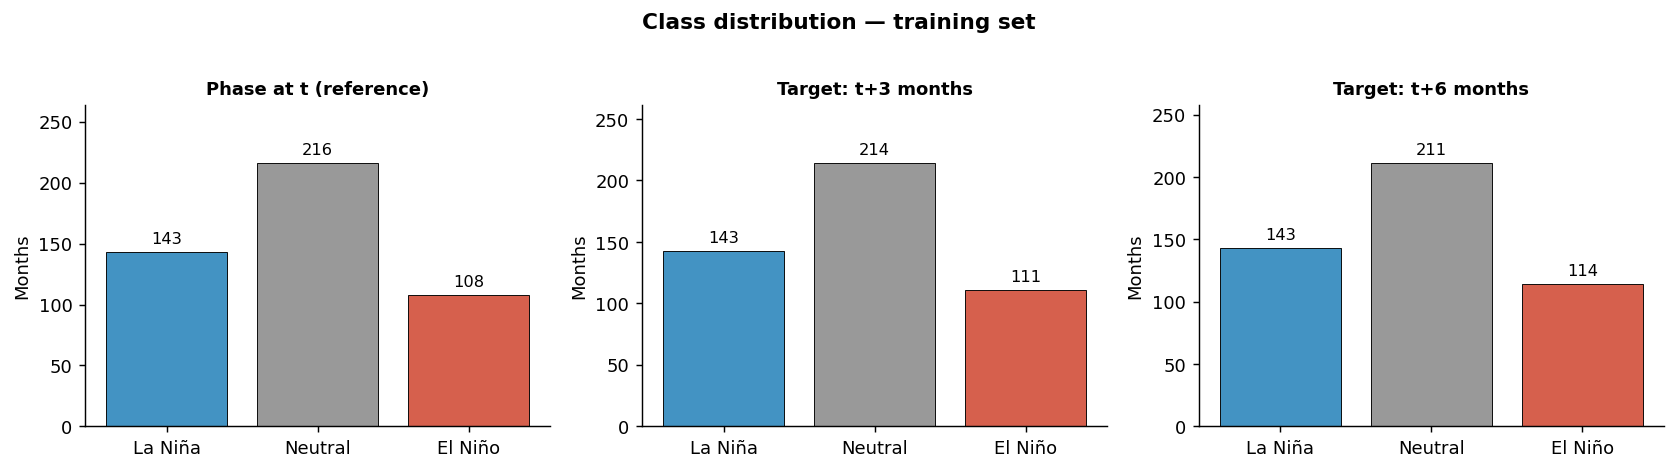

Neutral dominates → use macro F1, not accuracy, as your primary metric.
Train class balance: {'Neutral': 0.463, 'La Niña': 0.306, 'El Niño': 0.231}


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))

for ax, col, title in zip(
    axes,
    ['enso_phase', 'enso_t3', 'enso_t6'],
    ['Phase at t (reference)', 'Target: t+3 months', 'Target: t+6 months']
):
    counts = train[col].value_counts().reindex(LABEL_ORDER).fillna(0)
    bars = ax.bar(
        LABEL_ORDER, counts,
        color=[PHASE_COLORS[p] for p in LABEL_ORDER],
        edgecolor='black', linewidth=0.5
    )
    ax.bar_label(bars, fmt='%d', padding=3, fontsize=9)
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_ylabel('Months')
    ax.set_ylim(0, counts.max() * 1.22)

plt.suptitle('Class distribution — training set', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Neutral dominates → use macro F1, not accuracy, as your primary metric.')
print(f"Train class balance: {train['enso_phase'].value_counts(normalize=True).round(3).to_dict()}")

## 3. Niño 3.4 time series

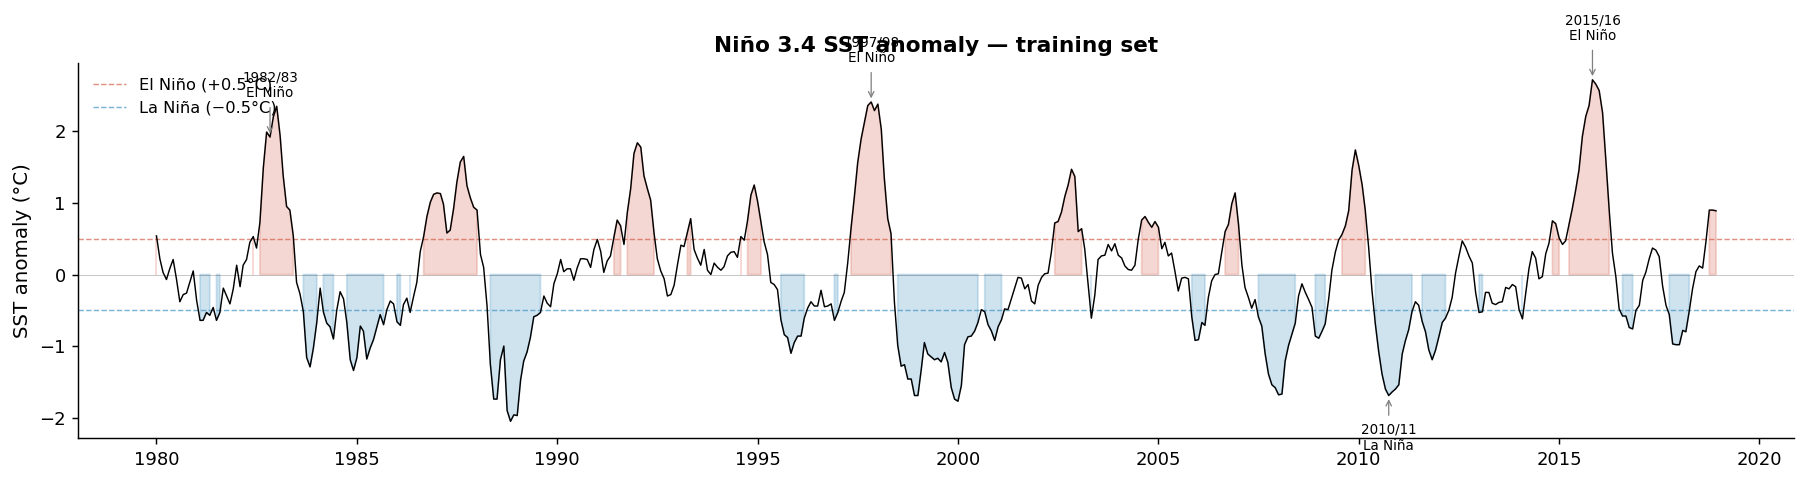

In [5]:
fig, ax = plt.subplots(figsize=(14, 4))

x = train['date']
y = train['sst_anom_nino34']

ax.axhline( 0.5, color='#d6604d', linestyle='--', linewidth=0.8, alpha=0.7, label='El Niño (+0.5°C)')
ax.axhline(-0.5, color='#4393c3', linestyle='--', linewidth=0.8, alpha=0.7, label='La Niña (−0.5°C)')
ax.axhline( 0.0, color='black',   linestyle='-',  linewidth=0.4, alpha=0.3)
ax.fill_between(x, y, 0, where=(y >  0.5), color='#d6604d', alpha=0.25)
ax.fill_between(x, y, 0, where=(y < -0.5), color='#4393c3', alpha=0.25)
ax.plot(x, y, color='black', linewidth=0.8)

# Annotate famous events (only if dates are in range)
events = [
    ('1982-11-01', '1982/83\nEl Niño'),
    ('1997-11-01', '1997/98\nEl Niño'),
    ('2010-10-01', '2010/11\nLa Niña'),
    ('2015-11-01', '2015/16\nEl Niño'),
]
for date_str, label in events:
    ts  = pd.Timestamp(date_str)
    row = train[train['date'] == ts]
    if not row.empty:
        val = row['sst_anom_nino34'].iloc[0]
        offset = 22 if val > 0 else -30
        ax.annotate(label, xy=(ts, val), xytext=(0, offset),
                    textcoords='offset points', fontsize=7.5, ha='center',
                    arrowprops=dict(arrowstyle='->', color='gray', lw=0.7))

ax.set_ylabel('SST anomaly (°C)', fontsize=11)
ax.set_title('Niño 3.4 SST anomaly — training set', fontsize=12, fontweight='bold')
ax.legend(fontsize=9, frameon=False, loc='upper left')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## 4. Seasonal patterns — spring predictability barrier

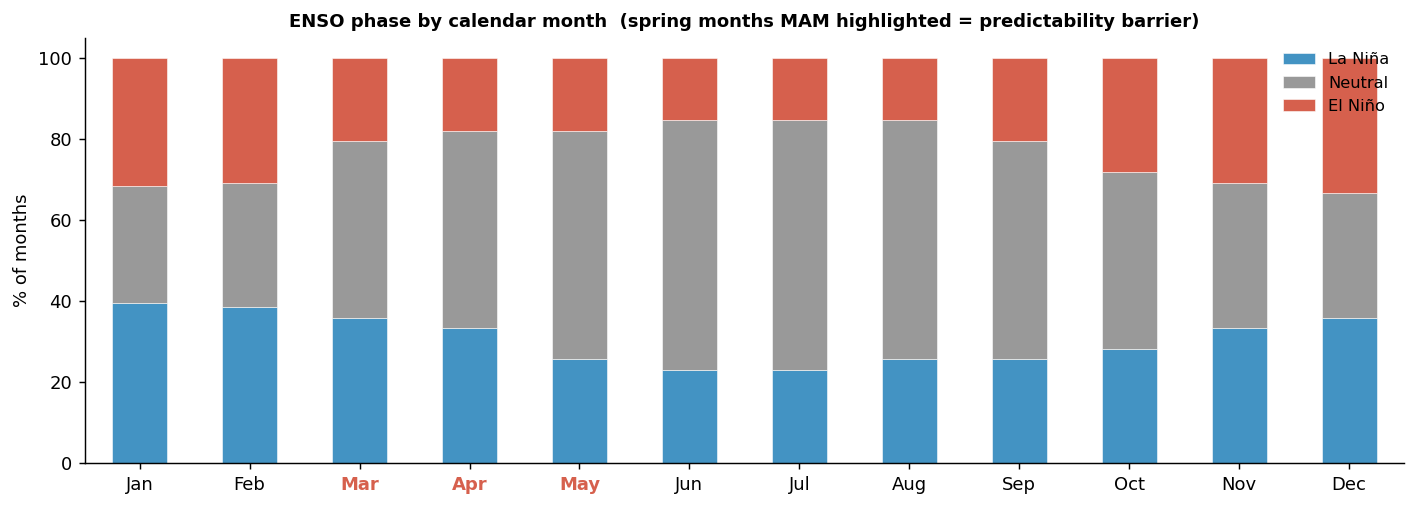

In [6]:
tmp = train.copy()
tmp['month_num'] = train['date'].dt.month
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

pivot = tmp.groupby(['month_num', 'enso_phase']).size().unstack(fill_value=0)
pivot = pivot.reindex(columns=LABEL_ORDER, fill_value=0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
pivot_pct.index = month_names

fig, ax = plt.subplots(figsize=(11, 4))
pivot_pct.plot(
    kind='bar', stacked=True, ax=ax,
    color=[PHASE_COLORS[p] for p in LABEL_ORDER],
    edgecolor='white', linewidth=0.3
)
# Highlight spring months
for i, m in enumerate(month_names):
    if m in ('Mar', 'Apr', 'May'):
        ax.get_xticklabels()[i].set_color('#d6604d')
        ax.get_xticklabels()[i].set_fontweight('bold')

ax.set_xlabel('')
ax.set_ylabel('% of months', fontsize=10)
ax.set_title('ENSO phase by calendar month  (spring months MAM highlighted = predictability barrier)',
             fontsize=10, fontweight='bold')
ax.legend(LABEL_ORDER, loc='upper right', fontsize=9, frameon=False)
ax.set_xticklabels(month_names, rotation=0)
plt.tight_layout()
plt.show()

## 5. Feature–target correlations

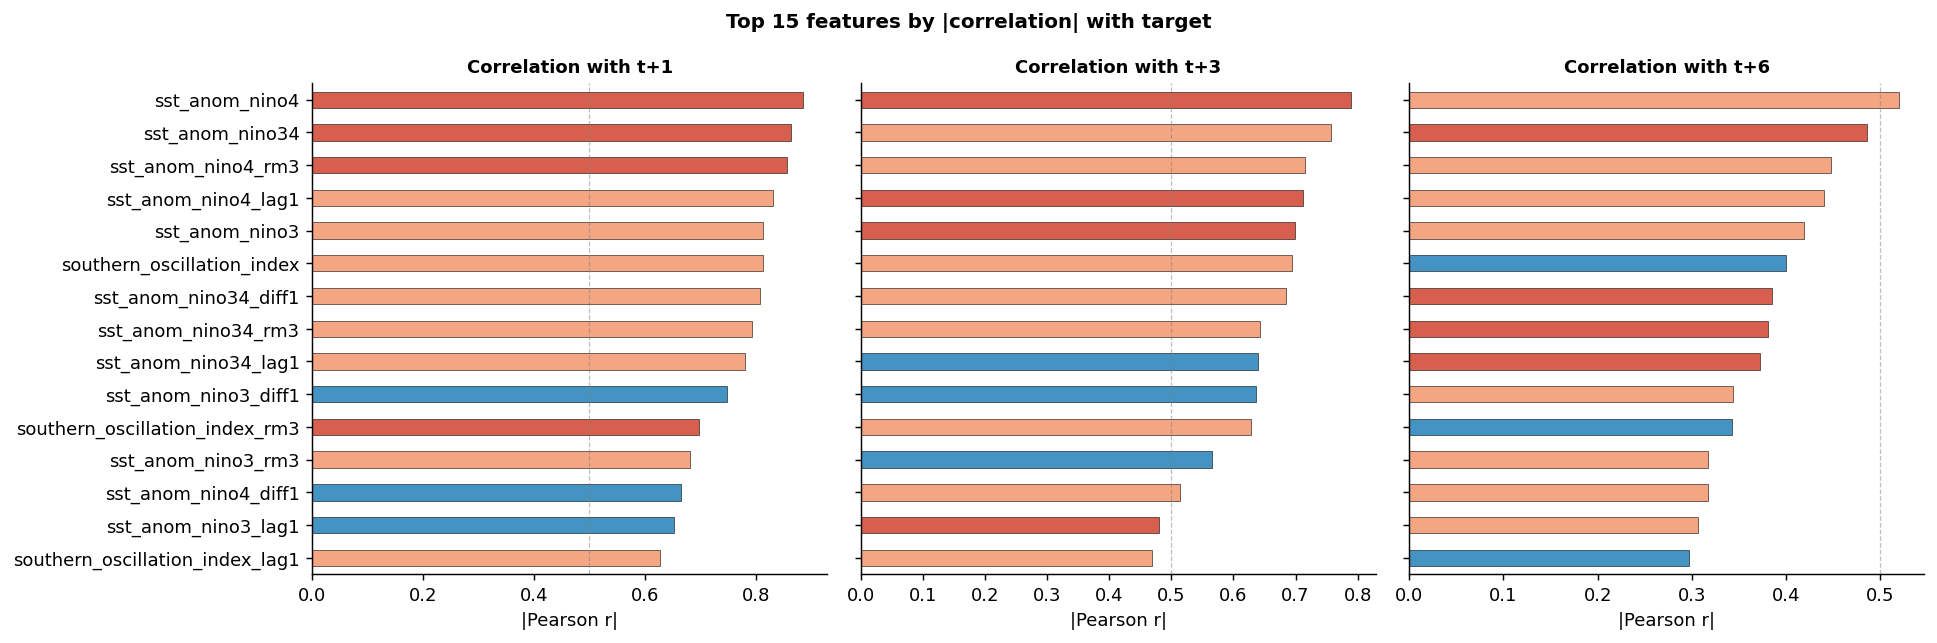

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, target_int, title in zip(
    axes,
    ['enso_t1_int', 'enso_t3_int', 'enso_t6_int'],
    ['Correlation with t+1', 'Correlation with t+3', 'Correlation with t+6']
):
    corrs = (train[FEATURE_COLS]
             .corrwith(train[target_int])
             .abs()
             .sort_values(ascending=False)
             .head(15))

    colors = ['#d6604d' if 'nino34' in c else
              '#4393c3' if 'oscillation' in c else
              '#66c2a5' if 'wind' in c else
              '#f4a582' if 'nino' in c else '#cccccc'
              for c in corrs.index]

    corrs.sort_values().plot(
        kind='barh', ax=ax,
        color=list(reversed(colors)),
        edgecolor='black', linewidth=0.3
    )
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_xlabel('|Pearson r|')
    ax.axvline(0.5, color='gray', linestyle='--', linewidth=0.7, alpha=0.5)

plt.suptitle('Top 15 features by |correlation| with target', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Simple baseline: Logistic Regression

In [8]:
def prepare(df, feature_cols, target):
    """Return X, y with NaN rows dropped. X is always numeric."""
    cols = [c for c in feature_cols if c in df.columns]
    mask = df[target].notna()
    X = df.loc[mask, cols].fillna(0)
    y = df.loc[mask, target]
    return X, y


def evaluate(y_true, y_pred, name=''):
    """Compute accuracy and macro F1, return results dict."""
    yt = np.array(y_true)
    yp = np.array(y_pred)
    mask = pd.notna(yt) & pd.notna(yp)
    yt, yp = yt[mask], yp[mask]
    acc = accuracy_score(yt, yp)
    f1  = f1_score(yt, yp, average='macro', zero_division=0, labels=LABEL_ORDER)
    cm  = confusion_matrix(yt, yp, labels=LABEL_ORDER)
    print(f'  {name:45s}  acc={acc:.3f}  f1_macro={f1:.3f}  n={len(yt)}')
    return {'name': name, 'accuracy': acc, 'f1_macro': f1, 'cm': cm, 'n': len(yt)}


le = LabelEncoder().fit(LABEL_ORDER)
sc = StandardScaler()

lr_results = {}
print('Logistic Regression — 8 core features\n')

for target in TARGETS:
    X_tr, y_tr = prepare(train, CORE_FEATURES, target)
    X_te, y_te = prepare(test,  CORE_FEATURES, target)

    X_tr_sc = sc.fit_transform(X_tr)
    X_te_sc = sc.transform(X_te)

    lr = LogisticRegression(
        C=1.0, max_iter=2000,
        class_weight='balanced', random_state=42
    )
    lr.fit(X_tr_sc, le.transform(y_tr))
    preds = le.inverse_transform(lr.predict(X_te_sc))
    lr_results[target] = evaluate(y_te, preds, name=f'LR core / {target}')

Logistic Regression — 8 core features

  LR core / enso_t1                              acc=0.956  f1_macro=0.963  n=90
  LR core / enso_t3                              acc=0.807  f1_macro=0.802  n=88
  LR core / enso_t6                              acc=0.624  f1_macro=0.608  n=85


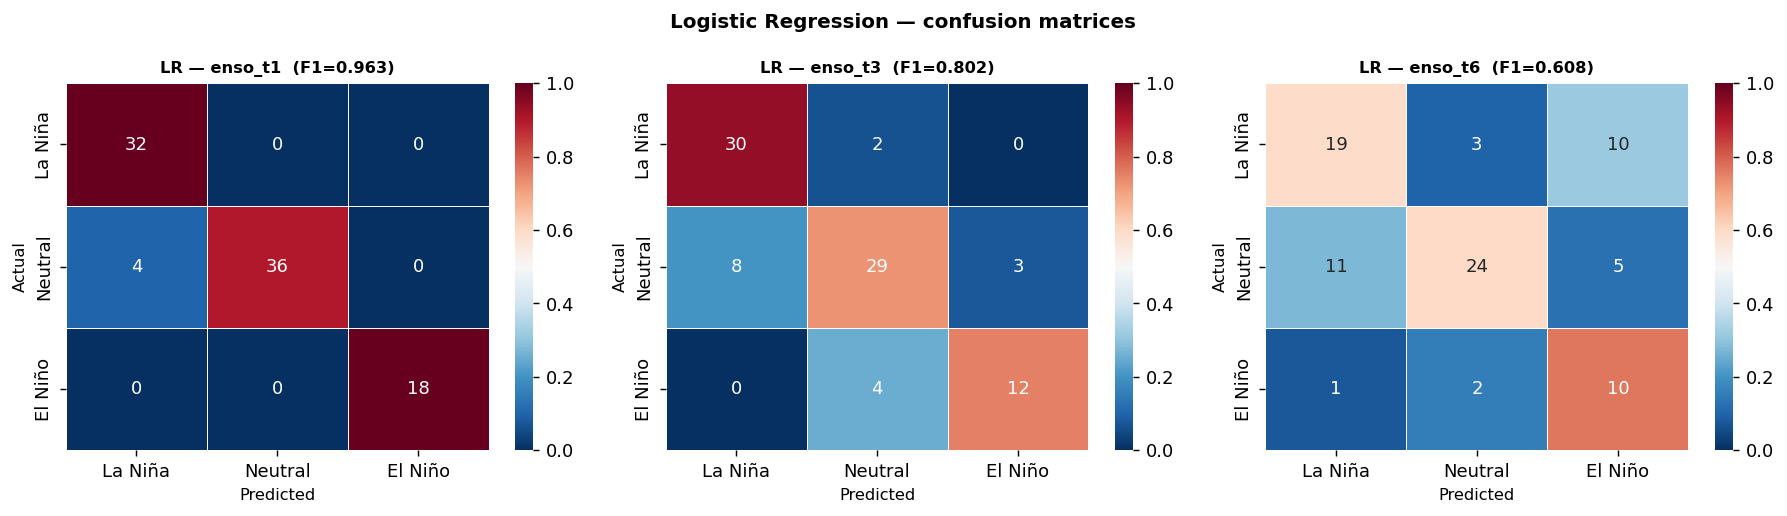

In [9]:
# Confusion matrix for t+3
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, target in zip(axes, TARGETS):
    cm = lr_results[target]['cm']
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)
    sns.heatmap(
        cm_norm, annot=cm, fmt='d', cmap='RdBu_r',
        vmin=0, vmax=1,
        xticklabels=['La Niña', 'Neutral', 'El Niño'],
        yticklabels=['La Niña', 'Neutral', 'El Niño'],
        linewidths=0.5, ax=ax
    )
    ax.set_xlabel('Predicted', fontsize=9)
    ax.set_ylabel('Actual', fontsize=9)
    ax.set_title(f'LR — {target}  (F1={lr_results[target]["f1_macro"]:.3f})',
                 fontsize=9, fontweight='bold')

plt.suptitle('Logistic Regression — confusion matrices', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Stronger model: LightGBM

In [10]:
lgb_results = {}
lgb_models  = {}

if not LGB_AVAILABLE:
    print('LightGBM not installed — skipping. Run: pip install lightgbm')
else:
    print('LightGBM — all features\n')
    for target in TARGETS:
        X_tr, y_tr = prepare(train, FEATURE_COLS, target)
        X_te, y_te = prepare(test,  FEATURE_COLS, target)

        model = lgb.LGBMClassifier(
            n_estimators=500,
            learning_rate=0.05,
            num_leaves=31,
            min_child_samples=20,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1,
            verbosity=-1,
        )
        model.fit(
            X_tr, le.transform(y_tr),
            eval_set=[(X_te, le.transform(y_te))],
            eval_metric='multi_logloss',
            callbacks=[lgb.early_stopping(50, verbose=False),
                       lgb.log_evaluation(period=-1)],
        )
        preds = le.inverse_transform(model.predict(X_te))
        lgb_results[target] = evaluate(y_te, preds, name=f'LightGBM / {target}')
        lgb_models[target]  = model

    print()
    print('Published benchmark results (test set 2019–2026):')
    print('  enso_t1  LightGBM F1=0.945  |  Persistence F1=0.858')
    print('  enso_t3  LR       F1=0.790  |  Persistence F1=0.610')
    print('  enso_t6  RF       F1=0.556  |  Persistence F1=0.419')

LightGBM — all features

  LightGBM / enso_t1                             acc=0.944  f1_macro=0.945  n=90
  LightGBM / enso_t3                             acc=0.761  f1_macro=0.761  n=88
  LightGBM / enso_t6                             acc=0.529  f1_macro=0.517  n=85

Published benchmark results (test set 2019–2026):
  enso_t1  LightGBM F1=0.945  |  Persistence F1=0.858
  enso_t3  LR       F1=0.790  |  Persistence F1=0.610
  enso_t6  RF       F1=0.556  |  Persistence F1=0.419


## 8. Feature importance (SHAP)

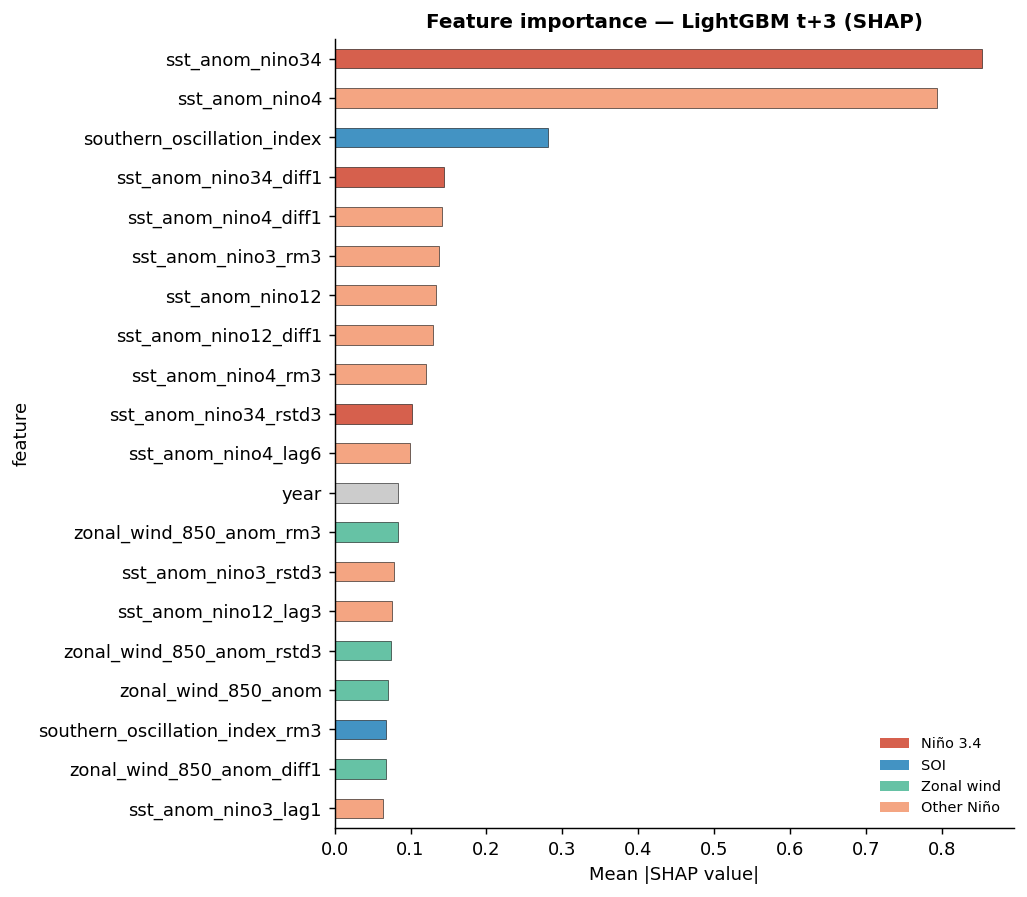


Top 5 features for t+3:
                   feature  mean_abs_shap
           sst_anom_nino34       0.852586
            sst_anom_nino4       0.793169
southern_oscillation_index       0.281720
     sst_anom_nino34_diff1       0.143554
      sst_anom_nino4_diff1       0.141253


In [11]:
if not SHAP_AVAILABLE:
    print('shap not installed — skipping. Run: pip install shap')
elif not lgb_results:
    print('LightGBM results not available — run section 7 first')
else:
    X_tr_t3, _ = prepare(train, FEATURE_COLS, 'enso_t3')

    explainer   = shap.TreeExplainer(lgb_models['enso_t3'])
    shap_values = explainer.shap_values(X_tr_t3)

    # shap_values can be a list (one array per class) or a 3D array
    # depending on shap version — handle both
    if isinstance(shap_values, list):
        # older shap: list of (n_samples, n_features) arrays
        mean_abs = np.abs(np.stack(shap_values)).mean(axis=(0, 1))
    else:
        # newer shap: (n_samples, n_features, n_classes)
        mean_abs = np.abs(shap_values).mean(axis=(0, 2))

    shap_df = (
        pd.DataFrame({'feature': FEATURE_COLS, 'mean_abs_shap': mean_abs})
        .sort_values('mean_abs_shap', ascending=False)
        .head(20)
    )

    fig, ax = plt.subplots(figsize=(8, 7))
    colors = [
        '#d6604d' if 'nino34' in c else
        '#4393c3' if 'oscillation' in c else
        '#66c2a5' if 'wind' in c else
        '#f4a582' if 'nino' in c else '#cccccc'
        for c in shap_df['feature']
    ]
    shap_df.sort_values('mean_abs_shap').plot(
        kind='barh', x='feature', y='mean_abs_shap',
        ax=ax, color=list(reversed(colors)),
        edgecolor='black', linewidth=0.3, legend=False
    )
    ax.set_xlabel('Mean |SHAP value|', fontsize=10)
    ax.set_title('Feature importance — LightGBM t+3 (SHAP)', fontsize=11, fontweight='bold')

    from matplotlib.patches import Patch
    ax.legend(handles=[
        Patch(facecolor='#d6604d', label='Niño 3.4'),
        Patch(facecolor='#4393c3', label='SOI'),
        Patch(facecolor='#66c2a5', label='Zonal wind'),
        Patch(facecolor='#f4a582', label='Other Niño'),
    ], fontsize=8, frameon=False, loc='lower right')

    plt.tight_layout()
    plt.show()

    print('\nTop 5 features for t+3:')
    print(shap_df.head(5)[['feature', 'mean_abs_shap']].to_string(index=False))

## 9. Lead-time performance curve

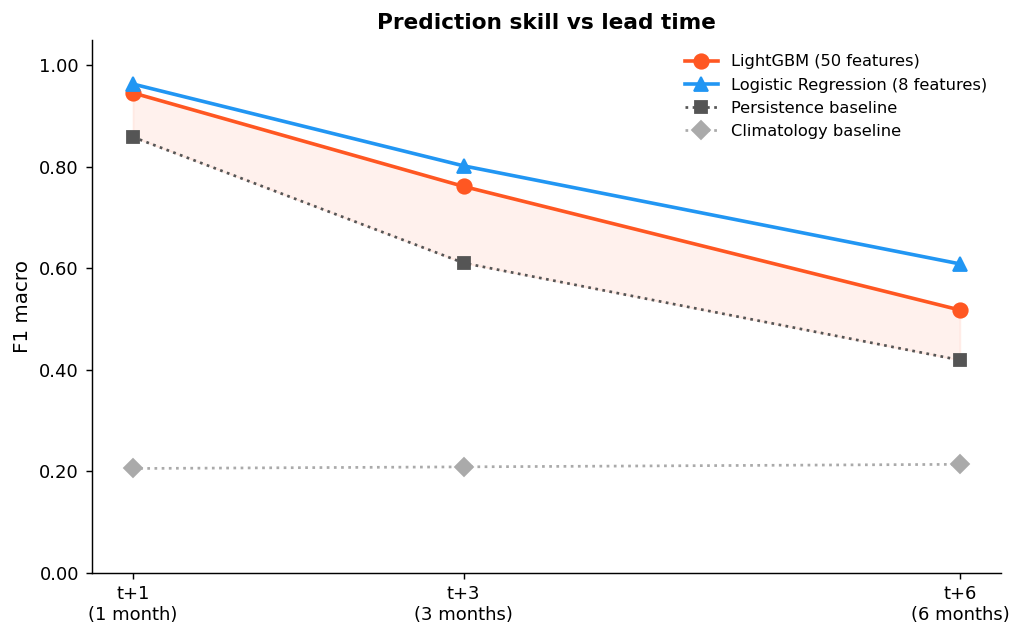

 target  persistence  LR_core  LightGBM
enso_t1        0.858    0.963     0.945
enso_t3        0.610    0.802     0.761
enso_t6        0.419    0.608     0.517


In [12]:
# ── Compute baselines on test set ─────────────────────────────────────────────
modal_class = train['enso_phase'].value_counts().idxmax()

pers_f1 = {}
clim_f1 = {}

for target in TARGETS:
    # Only use rows where both enso_phase and target are not NaN
    mask   = test[target].notna() & test['enso_phase'].notna()
    y_te   = test.loc[mask, target]
    y_pers = test.loc[mask, 'enso_phase']          # persistence: current phase
    y_clim = [modal_class] * mask.sum()             # climatology: always modal

    pers_f1[target] = f1_score(y_te, y_pers, average='macro',
                                zero_division=0, labels=LABEL_ORDER)
    clim_f1[target] = f1_score(y_te, y_clim, average='macro',
                                zero_division=0, labels=LABEL_ORDER)

lead_times = [1, 3, 6]

lr_f1_vals  = [lr_results[t]['f1_macro']        for t in TARGETS]
lgb_f1_vals = [lgb_results[t]['f1_macro']       for t in TARGETS] if lgb_results else None
pers_f1_vals = [pers_f1[t]                      for t in TARGETS]
clim_f1_vals = [clim_f1[t]                      for t in TARGETS]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

if lgb_f1_vals:
    ax.plot(lead_times, lgb_f1_vals, '-o', color='#FF5722',
            linewidth=2, markersize=8, label='LightGBM (50 features)')
    ax.fill_between(lead_times, pers_f1_vals, lgb_f1_vals,
                    alpha=0.08, color='#FF5722')

ax.plot(lead_times, lr_f1_vals,   '-^', color='#2196F3',
        linewidth=2, markersize=8, label='Logistic Regression (8 features)')
ax.plot(lead_times, pers_f1_vals, ':s', color='#555555',
        linewidth=1.5, markersize=7, label='Persistence baseline')
ax.plot(lead_times, clim_f1_vals, ':D', color='#aaaaaa',
        linewidth=1.5, markersize=7, label='Climatology baseline')

ax.set_xticks(lead_times)
ax.set_xticklabels(['t+1\n(1 month)', 't+3\n(3 months)', 't+6\n(6 months)'], fontsize=10)
ax.set_ylabel('F1 macro', fontsize=11)
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
ax.set_title('Prediction skill vs lead time', fontsize=12, fontweight='bold')
ax.legend(fontsize=9, frameon=False)
plt.tight_layout()
plt.show()

# Summary table
rows = []
for i, t in enumerate(TARGETS):
    row = {'target': t, 'persistence': round(pers_f1_vals[i], 3),
           'LR_core': round(lr_f1_vals[i], 3)}
    if lgb_f1_vals:
        row['LightGBM'] = round(lgb_f1_vals[i], 3)
    rows.append(row)

print(pd.DataFrame(rows).to_string(index=False))

## 10. What to try next

The **t+6 result (F1≈0.55) has the most headroom** — that's where the real challenge is. Here are directions worth exploring:

---

### 🔬 Feature ideas

| Idea | Why it matters |
|---|---|
| **MJO features** | The Madden-Julian Oscillation is a known ENSO precursor at 30–90 day timescales. BOM publishes daily RMM indices (phase + amplitude). |
| **Thermocline depth (D20)** | Depth of the 20°C isotherm captures subsurface heat content — a leading indicator of El Niño development weeks before SST signals appear. |
| **Longer lags (9, 12 months)** | The annual ENSO recharge cycle may leave useful signal at lags beyond 6 months. |
| **Cross-basin indices** | Atlantic SST anomalies and Indian Ocean Dipole have teleconnections with ENSO that aren't captured here. |

### 🤖 Modelling ideas

- **Walk-forward CV** — The `src/validation/splits.py` module in the [dataset repo](https://github.com/ferariz/enso-forecast) has a ready-made implementation. More reliable than a single train/test split for hyperparameter tuning.
- **Sequence models** — LSTM or Transformer directly on the raw monthly time series, bypassing hand-crafted lags entirely.
- **Probabilistic output** — Predict phase *probabilities* rather than hard labels. More actionable for operational forecasting and easier to calibrate.
- **Ensemble** — Blend LR and LightGBM weighted by lead time (LR at t+6, LightGBM at t+1).

### 📏 Evaluation ideas

- **Heidke Skill Score (HSS)** — The standard meteorological metric for categorical ENSO forecasts. Directly comparable to operational forecast centres.
- **El Niño onset detection** — Reframe as a binary task: does an El Niño *start* within the next 6 months? Operationally more useful than phase classification.
- **Reliability diagrams** — If you go probabilistic, plot calibration curves to verify your confidence scores are trustworthy.

---

> 💡 **Tip:** The dataset repo includes the full pipeline — ingestion, feature engineering, leakage checks, and baselines — so you can extend it rather than starting from scratch.